# DATA ANALYSIS INSIGHTS AND LOAD

Preprocessing and data transformation

In [1]:
# import libraries
import pandas as pd 
import numpy as np 
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats


In [2]:
# load the file and dataset
#file_path = ("/data/ESK10705.csv")
df = pd.read_csv("data/ESK10705.csv")
df2 = pd.read_csv("data/Prepaid_electricity_by_suburb.csv")
# Check if first column is mistakenly set as index
df.reset_index(inplace=True)



In [3]:
# Shift column headers left
df.columns = df.columns[1:].to_list() + [df.columns[0]]

In [4]:
# Convert DateTime column to actual datetime format
df["Date Time Hour Beginning"] = pd.to_datetime(df["Date Time Hour Beginning"], errors="coerce")



# Convert DateTime to numeric (UNIX timestamp in seconds)
#df["Date Time Hour Beginning"] = df["Date Time Hour Beginning"].astype("int64") // 10**9  # Convert to seconds

In [5]:
#Display the basic information of the dataset
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 43 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   Date Time Hour Beginning               43824 non-null  datetime64[ns]
 1   Original Res Forecast before Lockdown  24120 non-null  float64       
 2   Residual Forecast                      43824 non-null  float64       
 3   RSA Contracted Forecast                43824 non-null  float64       
 4   Dispatchable Generation                39240 non-null  float64       
 5   Residual Demand                        39240 non-null  float64       
 6   RSA Contracted Demand                  39240 non-null  float64       
 7   International Exports                  39240 non-null  float64       
 8   International Imports                  39240 non-null  float64       
 9   Thermal Generation                     39240 non-null  float6

In [6]:
df.head()
df.describe()

,Original Res Forecast before Lockdown,Residual Forecast,RSA Contracted Forecast,Dispatchable Generation,Residual Demand,RSA Contracted Demand,International Exports,International Imports,Thermal Generation,Nuclear Generation,...,Installed Eskom Capacity,Total PCLF,Total UCLF,Total OCLF,Total UCLF+OCLF,Non Comm Sentout,Drakensberg Gen Unit Hours,Palmiet Gen Unit Hours,Ingula Gen Unit Hours,index
count,24120.000000,43824.000000,43824.000000,39240.000000,39240.000000,39240.000000,39240.000000,39240.000000,39240.000000,39240.000000,...,39240.000000,39240.000000,39240.000000,39240.000000,39240.000000,39240.000000,39240.000000,39240.000000,39240.000000,39195.000000
mean,25696.925347,23700.770265,25547.244327,22973.649457,23741.517778,25585.334157,1419.392279,1190.605469,20240.458491,1116.229206,...,46474.117431,5224.077374,12618.057310,895.329616,13512.890443,451.386432,271.817542,81.952813,41.894341,38.319847
std,2976.391694,2799.966755,3117.433911,2867.049708,2909.497496,3186.250654,198.440842,234.755483,2062.035469,393.047135,...,734.245777,1674.349756,2798.536562,623.097283,2575.247684,305.519835,389.300775,11.150085,9.508021,9.795411
min,17962.121000,14319.136000,15172.651000,13797.940000,13797.940000,14929.991000,587.054000,0.000000,13774.000000,-47.584000,...,44926.000000,895.000000,4670.626000,0.000000,6545.000000,0.000000,0.000000,18.300000,9.100000,10.300000
25%,23179.918500,21469.599000,22744.575000,20783.069500,21454.851750,22744.998000,1275.258750,1105.000000,18807.717250,910.000000,...,46329.000000,4085.937500,10457.069750,432.609000,11518.000000,162.000000,0.000000,75.400000,35.500000,31.380000
50%,25975.684000,23831.508500,26120.454000,22868.432000,23856.108500,26163.909500,1407.869500,1198.000000,20167.625000,922.990000,...,46686.000000,5226.000000,12998.704500,723.572000,13788.500000,441.000000,0.000000,84.600000,43.700000,38.540000
75%,27773.274000,25627.277500,27977.289750,25042.186750,25734.662500,28011.403500,1554.288000,1355.711750,21690.732750,1407.000000,...,46800.000000,6306.240000,14765.524500,1259.820000,15430.000000,717.000000,544.000000,90.300000,49.600000,45.400000
max,34900.376000,33008.667000,34567.494000,32383.649000,34029.030000,35004.746000,2298.443000,1765.000000,26591.300000,1852.000000,...,47520.000000,11289.417000,19507.807000,5219.432000,21535.000000,1268.000000,1957.000000,102.000000,58.700000,66.400000


In [7]:
# For cape town dataset
df2.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7685 entries, 0 to 7684
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   area            7678 non-null   object 
 1   units_per_area  7685 non-null   float64
 2   txmonth         7685 non-null   object 
 3   number_in_area  7685 non-null   int64  
 4   tariff          7685 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 300.3+ KB


In [8]:
# Summary of dataset 2
df2.head()

,area,units_per_area,txmonth,number_in_area,tariff
0,BEACON VALLEY,1009307.4,Nov-24,3447,Domestic
1,EASTRIDGE,810164.4,Nov-24,2860,Domestic
2,NaN,2672144.1,Nov-24,9403,Domestic
3,LENTEGEUR,1243236.9,Nov-24,4420,Domestic
4,ROCKLANDS,1075632.9,Nov-24,3669,Domestic


In [9]:
# Drop columns with too many missing values (threshold: 50% missing)
threshold = len(df) * 0.5
df = df.dropna(axis=1, thresh=threshold)
df.head()

,Date Time Hour Beginning,Original Res Forecast before Lockdown,Residual Forecast,RSA Contracted Forecast,Dispatchable Generation,Residual Demand,RSA Contracted Demand,International Exports,International Imports,Thermal Generation,...,Installed Eskom Capacity,Total PCLF,Total UCLF,Total OCLF,Total UCLF+OCLF,Non Comm Sentout,Drakensberg Gen Unit Hours,Palmiet Gen Unit Hours,Ingula Gen Unit Hours,index
0,2020-04-01 00:00:00,21964.211,15973.653,16700.031,15695.40,15695.40,16758.232,1704.954,1069.0,15560.0,...,45017.0,8954.3,8233.256,903.962,9137.0,218.0,498.0,86.2,44.8,21.69
1,2020-04-01 01:00:00,21486.852,15649.973,16357.728,15450.27,15450.27,16401.964,1716.990,938.0,15423.0,...,45017.0,8930.0,8224.320,903.962,9128.0,282.0,495.0,88.2,46.8,24.79
2,2020-04-01 02:00:00,21366.136,15452.154,16136.543,15211.40,15211.40,16136.822,1691.063,848.0,15319.0,...,45017.0,8930.0,8284.563,903.962,9188.0,525.0,492.0,89.7,48.0,28.22
3,2020-04-01 03:00:00,21535.832,15572.487,16222.955,15206.27,15206.27,16169.168,1657.440,831.0,15317.0,...,45017.0,8751.4,8571.934,903.962,9475.0,896.0,492.0,91.2,50.0,31.44
4,2020-04-01 04:00:00,22623.152,16011.992,16623.471,15574.27,15574.27,16502.843,1640.295,944.0,15506.0,...,45017.0,8742.0,8406.206,903.962,9310.0,168.0,499.0,93.0,52.0,34.79


In [10]:
# Fill remaining missing values with column mean
df.fillna(df.mean(), inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_12368\2772816096.py:2: FutureWarning: DataFrame.mean and DataFrame.median with numeric_only=None will include datetime64 and datetime64tz columns in a future version.
  df.fillna(df.mean(), inplace=True)


In [11]:
# Display updated dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 43 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   Date Time Hour Beginning               43824 non-null  datetime64[ns]
 1   Original Res Forecast before Lockdown  43824 non-null  float64       
 2   Residual Forecast                      43824 non-null  float64       
 3   RSA Contracted Forecast                43824 non-null  float64       
 4   Dispatchable Generation                43824 non-null  float64       
 5   Residual Demand                        43824 non-null  float64       
 6   RSA Contracted Demand                  43824 non-null  float64       
 7   International Exports                  43824 non-null  float64       
 8   International Imports                  43824 non-null  float64       
 9   Thermal Generation                     43824 non-null  float6

In [12]:
df.head()

,Date Time Hour Beginning,Original Res Forecast before Lockdown,Residual Forecast,RSA Contracted Forecast,Dispatchable Generation,Residual Demand,RSA Contracted Demand,International Exports,International Imports,Thermal Generation,...,Installed Eskom Capacity,Total PCLF,Total UCLF,Total OCLF,Total UCLF+OCLF,Non Comm Sentout,Drakensberg Gen Unit Hours,Palmiet Gen Unit Hours,Ingula Gen Unit Hours,index
0,2020-04-01 00:00:00,21964.211,15973.653,16700.031,15695.40,15695.40,16758.232,1704.954,1069.0,15560.0,...,45017.0,8954.3,8233.256,903.962,9137.0,218.0,498.0,86.2,44.8,21.69
1,2020-04-01 01:00:00,21486.852,15649.973,16357.728,15450.27,15450.27,16401.964,1716.990,938.0,15423.0,...,45017.0,8930.0,8224.320,903.962,9128.0,282.0,495.0,88.2,46.8,24.79
2,2020-04-01 02:00:00,21366.136,15452.154,16136.543,15211.40,15211.40,16136.822,1691.063,848.0,15319.0,...,45017.0,8930.0,8284.563,903.962,9188.0,525.0,492.0,89.7,48.0,28.22
3,2020-04-01 03:00:00,21535.832,15572.487,16222.955,15206.27,15206.27,16169.168,1657.440,831.0,15317.0,...,45017.0,8751.4,8571.934,903.962,9475.0,896.0,492.0,91.2,50.0,31.44
4,2020-04-01 04:00:00,22623.152,16011.992,16623.471,15574.27,15574.27,16502.843,1640.295,944.0,15506.0,...,45017.0,8742.0,8406.206,903.962,9310.0,168.0,499.0,93.0,52.0,34.79


In [13]:
# Separate datetime column
datetime_col = df["Date Time Hour Beginning"]

# Drop DateTime for scaling
df_numeric = df.drop(columns=["Date Time Hour Beginning"])

# Initialize and apply scaler
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df_numeric)

# Apply PCA
pca = PCA(n_components=5)  # Keeping top 5 components
principal_components = pca.fit_transform(df_scaled)

# Explained variance ratio
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

explained_variance, cumulative_variance

# Convert back to DataFrame (optional)
df_scaled = pd.DataFrame(df_scaled, columns=df_numeric.columns)

# Add DateTime column back
df_scaled.insert(0, "Date Time Hour Beginning", datetime_col)

print(df_scaled.head())

  Date Time Hour Beginning  Original Res Forecast before Lockdown  \
0      2020-04-01 00:00:00                               0.236275   
1      2020-04-01 01:00:00                               0.208093   
2      2020-04-01 02:00:00                               0.200966   
3      2020-04-01 03:00:00                               0.210985   
4      2020-04-01 04:00:00                               0.275178   

   Residual Forecast  RSA Contracted Forecast  Dispatchable Generation  \
0           0.088526                 0.078752                 0.102092   
1           0.071208                 0.061103                 0.088903   
2           0.060623                 0.049698                 0.076051   
3           0.067062                 0.054154                 0.075775   
4           0.090578                 0.074804                 0.095575   

   Residual Demand  RSA Contracted Demand  International Exports  \
0         0.093789               0.091072               0.653212   
1   

In [14]:
print("Explained Variance Ratio:", explained_variance)
print("Cumulative Variance:", cumulative_variance)

Explained Variance Ratio: [0.33291754 0.17607652 0.08199601 0.06691243 0.0498646 ]
Cumulative Variance: [0.33291754 0.50899406 0.59099007 0.6579025  0.7077671 ]


In [15]:
""" Histograms & KDE:

A bell-shaped curve suggests normality.
Skewed or bimodal shapes indicate non-normality.
 """

' Histograms & KDE:\n\nA bell-shaped curve suggests normality.\nSkewed or bimodal shapes indicate non-normality.\n '

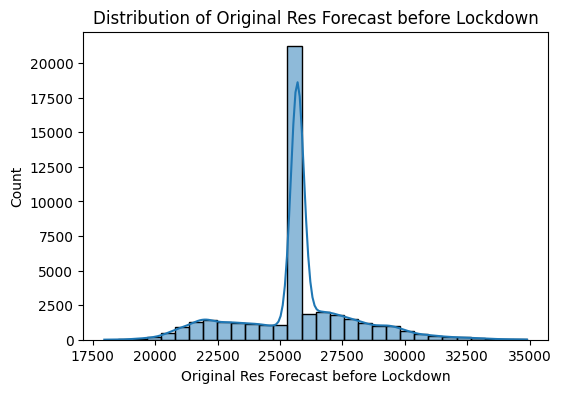

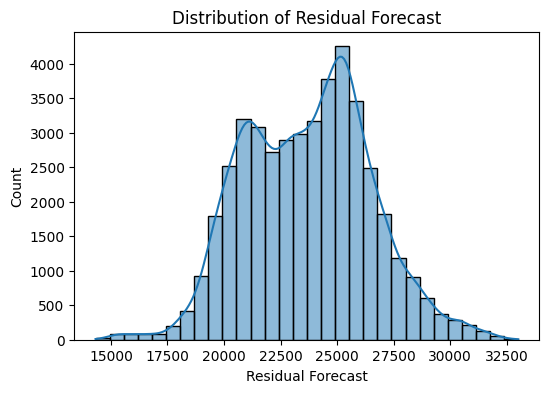

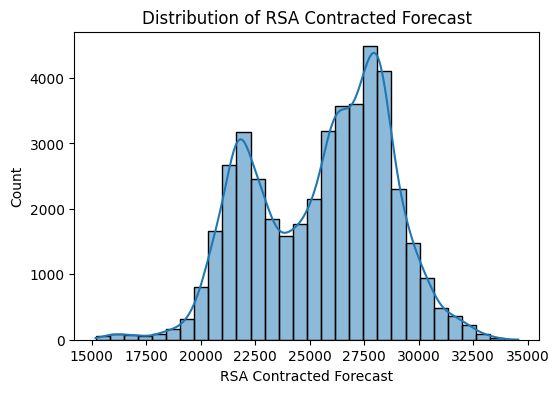

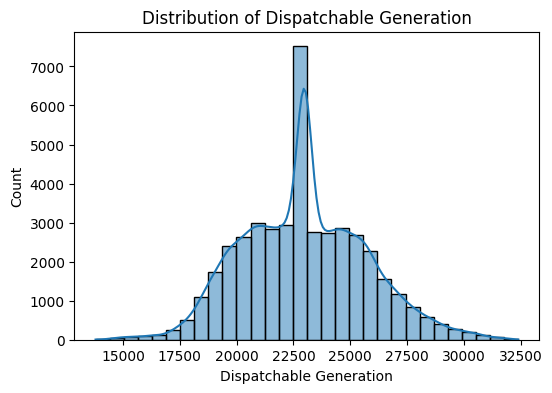

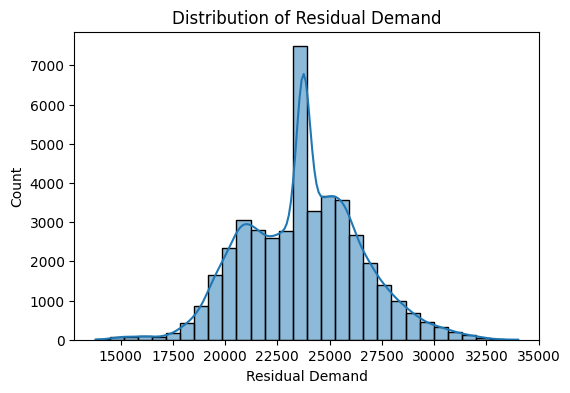

In [16]:
# Select numerical columns
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Plot histograms & KDE
for col in num_cols[:5]:  # Limit to first 5 columns for better visualization
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()


In [17]:
""" Q-Q Plot:

If data points lie on a straight line → Normal distribution.
Deviations suggest skewness or heavy tails. """

' Q-Q Plot:\n\nIf data points lie on a straight line → Normal distribution.\nDeviations suggest skewness or heavy tails. '

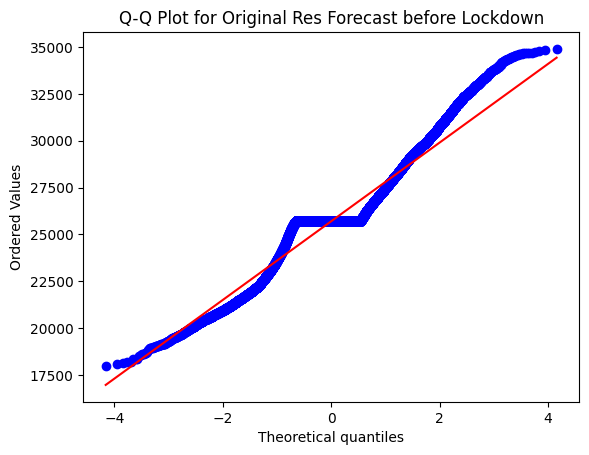

In [18]:
# Q-Q Plot for a sample column
sample_col = num_cols[0]
stats.probplot(df[sample_col], dist="norm", plot=plt)
plt.title(f'Q-Q Plot for {sample_col}')
plt.show()

In [19]:
""" Shapiro-Wilk Test:

p > 0.05 → Fail to reject normality (data might be normal).
p < 0.05 → Data is likely not normal. """

' Shapiro-Wilk Test:\n\np > 0.05 → Fail to reject normality (data might be normal).\np < 0.05 → Data is likely not normal. '

In [20]:
# Shapiro-Wilk test (only for datasets < 5000 samples)
stat, p = stats.shapiro(df[sample_col])
print(f'Shapiro-Wilk Test for {sample_col}: Statistic={stat}, p={p}')
if p > 0.05:
    print("Data is likely normally distributed.")
else:
    print("Data is not normally distributed.")

Shapiro-Wilk Test for Original Res Forecast before Lockdown: Statistic=0.9038184010363547, p=4.7218595286844896e-93
Data is not normally distributed.


c:\users\user\appdata\local\programs\python\python311\lib\site-packages\scipy\stats\_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 43824.
  res = hypotest_fun_out(*samples, **kwds)


In [21]:
# Check if there are any non-positive values for log transformation
sample_data = df[sample_col]

# Log transformation (only apply if all values are positive)
if (sample_data > 0).all():
    log_transformed = np.log(sample_data)
else:
    log_transformed = None

# Box-Cox transformation (only for positive values)
boxcox_transformed, boxcox_lambda = stats.boxcox(sample_data[sample_data > 0])

# Yeo-Johnson transformation (works for both positive and negative values)
yeojohnson_transformed, yeojohnson_lambda = stats.yeojohnson(sample_data)

# Prepare the data for display
transformed_data = {
    'Original': sample_data,
    'Log Transformation': log_transformed,
    'Box-Cox Transformation': boxcox_transformed if len(boxcox_transformed) > 0 else None,
    'Yeo-Johnson Transformation': yeojohnson_transformed
}

# Return the transformed data for display and further checks
transformed_data

{'Original': 0        21964.211000
 1        21486.852000
 2        21366.136000
 3        21535.832000
 4        22623.152000
              ...     
 43819    25696.925347
 43820    25696.925347
 43821    25696.925347
 43822    25696.925347
 43823    25696.925347
 Name: Original Res Forecast before Lockdown, Length: 43824, dtype: float64,
 'Log Transformation': 0         9.997170
 1         9.975196
 2         9.969563
 3         9.977473
 4        10.026729
            ...    
 43819    10.154127
 43820    10.154127
 43821    10.154127
 43822    10.154127
 43823    10.154127
 Name: Original Res Forecast before Lockdown, Length: 43824, dtype: float64,
 'Box-Cox Transformation': array([3193.23579673, 3138.76983984, 3124.95483291, ..., 3610.7678216 ,
        3610.7678216 , 3610.7678216 ]),
 'Yeo-Johnson Transformation': array([3193.01135342, 3138.55254612, 3124.73935225, ..., 3610.48846822,
        3610.48846822, 3610.48846822])}

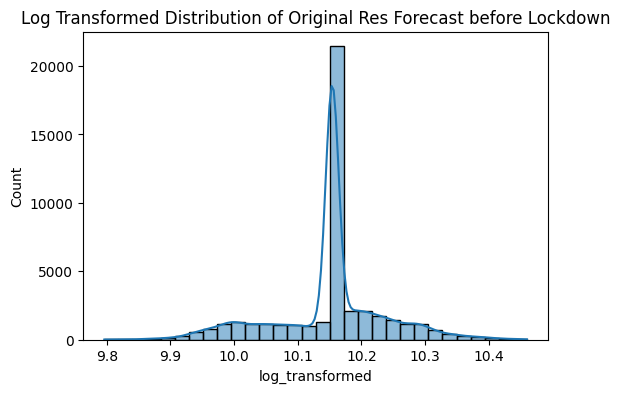

Shapiro-Wilk Test for Log Transformed Original Res Forecast before Lockdown: Statistic=0.9011116103154443, p=9.769905345296487e-94


c:\users\user\appdata\local\programs\python\python311\lib\site-packages\scipy\stats\_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 43824.
  res = hypotest_fun_out(*samples, **kwds)


In [22]:
# Check if all values are positive before applying log transformation
if (df[sample_col] > 0).all():
    df['log_transformed'] = np.log(df[sample_col])
else:
    print("Log transformation cannot be applied because there are non-positive values.")


# Box-Cox transformation (only for positive values)
positive_values = df[sample_col][df[sample_col] > 0]
boxcox_transformed, boxcox_lambda = stats.boxcox(positive_values)
df['boxcox_transformed'] = np.concatenate([boxcox_transformed, np.zeros(len(df) - len(positive_values))])

# Yeo-Johnson transformation (works for both positive and negative values)
yeojohnson_transformed, yeojohnson_lambda = stats.yeojohnson(df[sample_col])
df['yeojohnson_transformed'] = yeojohnson_transformed


# Visualize the transformed data
plt.figure(figsize=(6, 4))
sns.histplot(df['log_transformed'], kde=True, bins=30)
plt.title(f'Log Transformed Distribution of {sample_col}')
plt.show()

# Shapiro-Wilk test for normality
stat, p = stats.shapiro(df['log_transformed'])
print(f'Shapiro-Wilk Test for Log Transformed {sample_col}: Statistic={stat}, p={p}')


In [23]:
df.head()

,Date Time Hour Beginning,Original Res Forecast before Lockdown,Residual Forecast,RSA Contracted Forecast,Dispatchable Generation,Residual Demand,RSA Contracted Demand,International Exports,International Imports,Thermal Generation,...,Total OCLF,Total UCLF+OCLF,Non Comm Sentout,Drakensberg Gen Unit Hours,Palmiet Gen Unit Hours,Ingula Gen Unit Hours,index,log_transformed,boxcox_transformed,yeojohnson_transformed
0,2020-04-01 00:00:00,21964.211,15973.653,16700.031,15695.40,15695.40,16758.232,1704.954,1069.0,15560.0,...,903.962,9137.0,218.0,498.0,86.2,44.8,21.69,9.997170,3193.235797,3193.011353
1,2020-04-01 01:00:00,21486.852,15649.973,16357.728,15450.27,15450.27,16401.964,1716.990,938.0,15423.0,...,903.962,9128.0,282.0,495.0,88.2,46.8,24.79,9.975196,3138.769840,3138.552546
2,2020-04-01 02:00:00,21366.136,15452.154,16136.543,15211.40,15211.40,16136.822,1691.063,848.0,15319.0,...,903.962,9188.0,525.0,492.0,89.7,48.0,28.22,9.969563,3124.954833,3124.739352
3,2020-04-01 03:00:00,21535.832,15572.487,16222.955,15206.27,15206.27,16169.168,1657.440,831.0,15317.0,...,903.962,9475.0,896.0,492.0,91.2,50.0,31.44,9.977473,3144.370405,3144.152376
4,2020-04-01 04:00:00,22623.152,16011.992,16623.471,15574.27,15574.27,16502.843,1640.295,944.0,15506.0,...,903.962,9310.0,168.0,499.0,93.0,52.0,34.79,10.026729,3267.999606,3267.765344


# EXPLORATORY DATA ANALYSIS (EDA)

In [24]:
# Convert 'Date Time Hour Beginning' column to datetime format
df['Date Time Hour Beginning'] = pd.to_datetime(df['Date Time Hour Beginning'], errors='coerce')

# Set datetime column as index
df.set_index('Date Time Hour Beginning', inplace=True)

# Resample data weekly (summing up hourly averages)
df_weekly = df[['Residual Demand', 'RSA Contracted Demand', 'Residual Forecast']].resample('W').sum()

# Extract financial years
df_weekly['Year'] = df_weekly.index.year
df_weekly['FY'] = df_weekly.apply(lambda x: '2022-23' if x['Year'] == 2022 or (x['Year'] == 2023 and x.name.month <= 3) 
                                  else ('2023-24' if x['Year'] == 2023 or (x['Year'] == 2024 and x.name.month <= 3) else None), axis=1)

# Filter relevant financial years
df_weekly_filtered = df_weekly[df_weekly['FY'].notna()]

# Display sample of cleaned weekly data
df_weekly_filtered.head()


,Residual Demand,RSA Contracted Demand,Residual Forecast,Year,FY
Date Time Hour Beginning,,,,,
2022-01-02,3407134.521,3755089.937,3448190.440,2022,2022-23
2022-01-09,3681463.863,4031064.030,3698458.000,2022,2022-23
2022-01-16,3950999.257,4242735.741,3958851.296,2022,2022-23
2022-01-23,3973935.090,4288673.336,3999025.659,2022,2022-23
2022-01-30,4076473.147,4379837.755,4035798.710,2022,2022-23


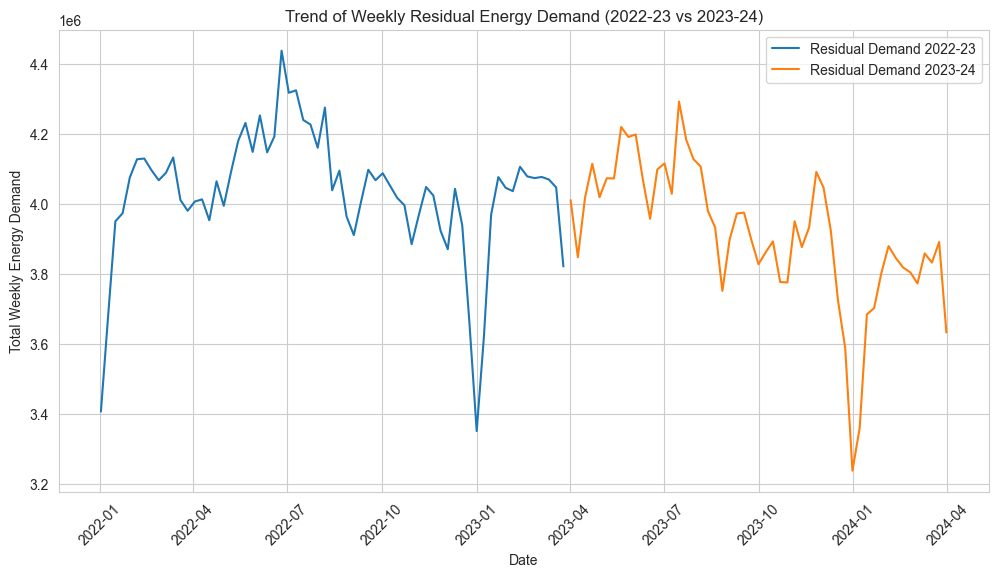

In [25]:
# Set plot style
sns.set_style("whitegrid")

# Plot weekly residual demand for both financial years
plt.figure(figsize=(12, 6))
for fy in ['2022-23', '2023-24']:
    subset = df_weekly_filtered[df_weekly_filtered['FY'] == fy]
    plt.plot(subset.index, subset['Residual Demand'], label=f'Residual Demand {fy}')

# Customize plot
plt.xlabel("Date")
plt.ylabel("Total Weekly Energy Demand")
plt.title("Trend of Weekly Residual Energy Demand (2022-23 vs 2023-24)")
plt.legend()
plt.xticks(rotation=45)
plt.show()


Weekly Peak Demand Data Sample:
                           Residual Demand  Year       FY
Date Time Hour Beginning                                
2022-01-02                      23895.871  2022  2022-23
2022-01-09                      25657.275  2022  2022-23
2022-01-16                      26516.769  2022  2022-23
2022-01-23                      27394.036  2022  2022-23
2022-01-30                      28435.058  2022  2022-23


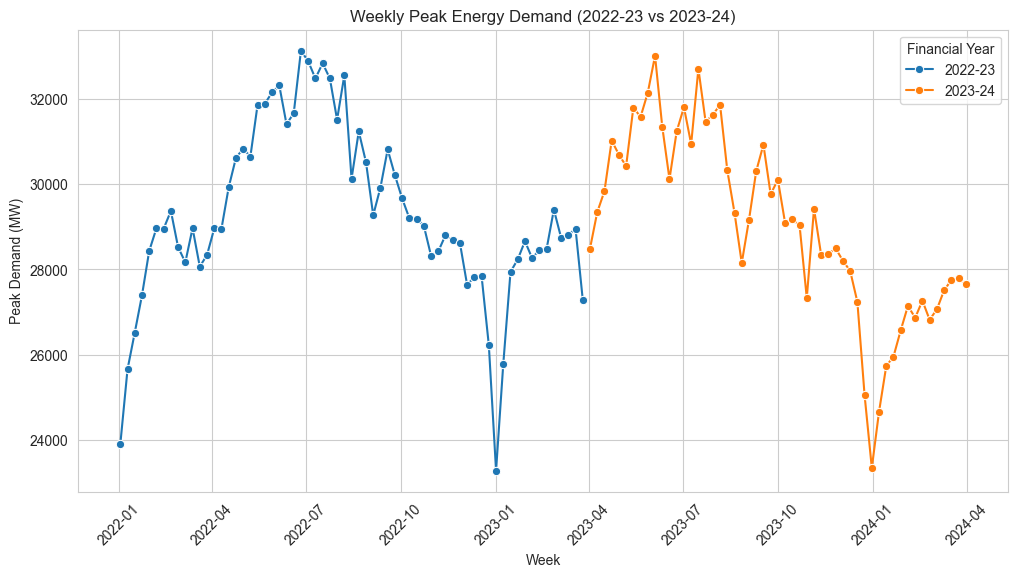

In [26]:
# Extract Weekly Peak Demand (Maximum Hourly Value per Week)
df_weekly_peak = df.resample('W')['Residual Demand'].max().to_frame()

# Add Year and Financial Year Columns
df_weekly_peak['Year'] = df_weekly_peak.index.year
df_weekly_peak['FY'] = df_weekly_peak.apply(lambda x: 
    '2022-23' if x['Year'] == 2022 or (x['Year'] == 2023 and x.name.month <= 3) 
    else ('2023-24' if x['Year'] == 2023 or (x['Year'] == 2024 and x.name.month <= 3) else None), axis=1)

# Keep Only Relevant Financial Years
df_weekly_filtered = df_weekly_peak[df_weekly_peak['FY'].notna()]

# Check Data Before Plotting
print("\nWeekly Peak Demand Data Sample:\n", df_weekly_filtered.head())

# Plot Weekly Peak Demand Trend
plt.figure(figsize=(12, 6))
sns.lineplot(x=df_weekly_filtered.index, y=df_weekly_filtered['Residual Demand'], hue=df_weekly_filtered['FY'], marker="o")

# Customize Plot
plt.xlabel("Week")
plt.ylabel("Peak Demand (MW)")
plt.title("Weekly Peak Energy Demand (2022-23 vs 2023-24)")
plt.legend(title="Financial Year")
plt.xticks(rotation=45)
plt.grid(True)

# Show Plot
plt.show()


Hourly Demand Sample:
                           Residual Demand  RSA Contracted Demand
Date Time Hour Beginning                                        
2020-04-01 00:00:00              15695.40              16758.232
2020-04-01 01:00:00              15450.27              16401.964
2020-04-01 02:00:00              15211.40              16136.822
2020-04-01 03:00:00              15206.27              16169.168
2020-04-01 04:00:00              15574.27              16502.843


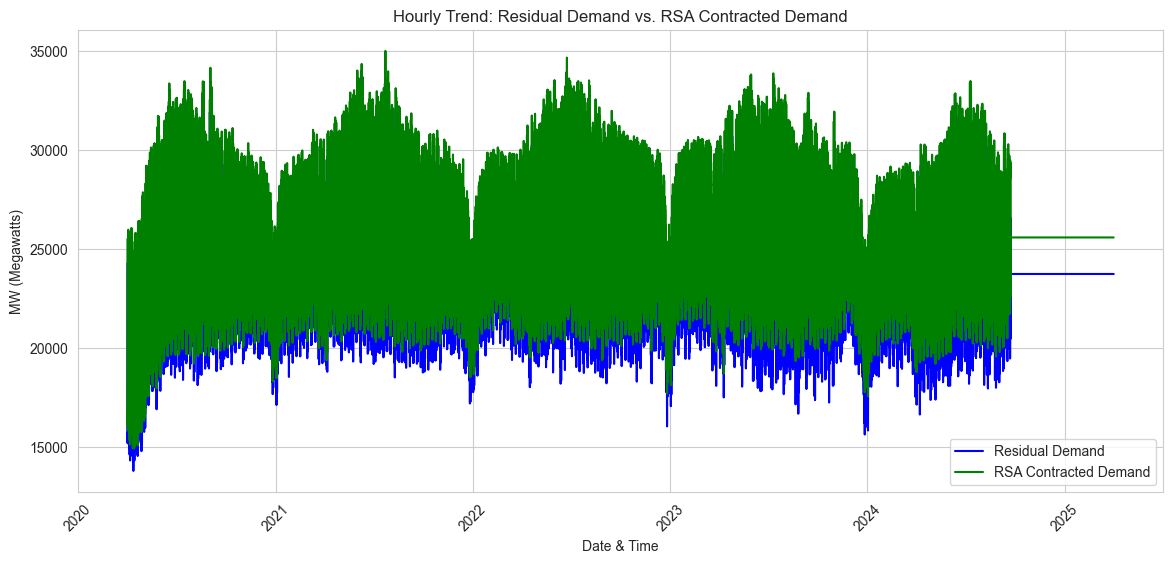

In [27]:
# Verify demand columns
demand_cols = ["Residual Demand", "RSA Contracted Demand"]
for col in demand_cols:
    if col not in df.columns:
        raise KeyError(f"Column '{col}' is missing in the dataset!")

# Convert Demand Columns to Numeric (if needed)
df[demand_cols] = df[demand_cols].apply(pd.to_numeric, errors='coerce')

# Check Data Before Plotting
print("\nHourly Demand Sample:\n", df[demand_cols].dropna().head())

# Plot Demand Trends
plt.figure(figsize=(14, 6))

# Plot Residual Demand & RSA Contracted Demand
sns.lineplot(x=df.index, y=df["Residual Demand"], label="Residual Demand", color="blue")
sns.lineplot(x=df.index, y=df["RSA Contracted Demand"], label="RSA Contracted Demand", color="green")

# Customize Plot
plt.xlabel("Date & Time")
plt.ylabel("MW (Megawatts)")
plt.title("Hourly Trend: Residual Demand vs. RSA Contracted Demand")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)

# Show Plot
plt.show()


Monthly Demand Sample for 2023:
                           Residual Demand  RSA Contracted Demand
Date Time Hour Beginning                                        
2023-01-31                   1.735948e+07           1.898675e+07
2023-02-28                   1.630387e+07           1.769581e+07
2023-03-31                   1.772971e+07           1.930156e+07
2023-04-30                   1.712170e+07           1.844292e+07
2023-05-31                   1.845245e+07           1.970997e+07


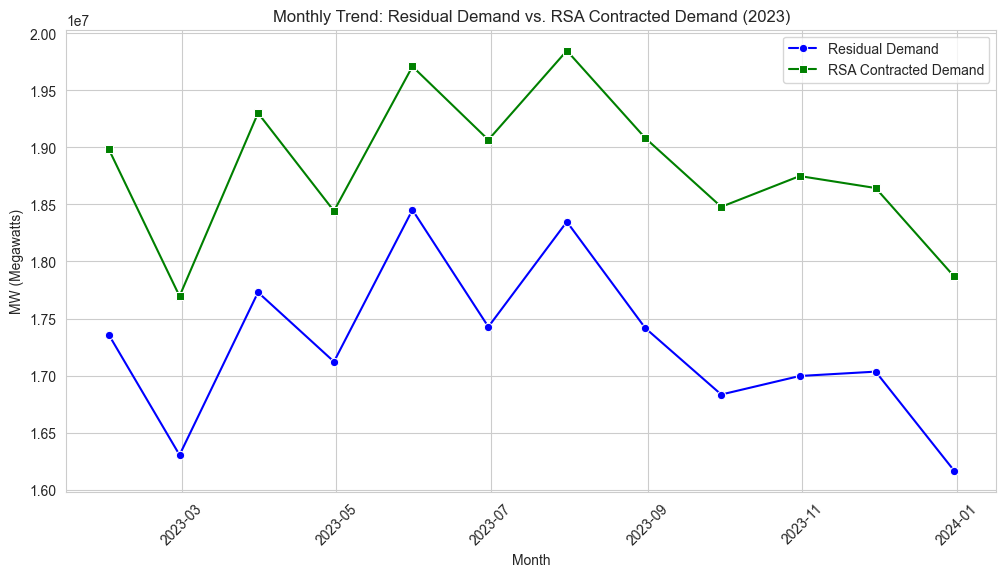

In [28]:
# Verify demand columns
demand_cols = ["Residual Demand", "RSA Contracted Demand"]
for col in demand_cols:
    if col not in df.columns:
        raise KeyError(f"Column '{col}' is missing in the dataset!")

# Convert Demand Columns to Numeric (if needed)
df[demand_cols] = df[demand_cols].apply(pd.to_numeric, errors='coerce')

# Filter Data for 2023
df_2023 = df.loc['2023']

# Resample to Monthly Data (Using Sum or Mean)
df_monthly_2023 = df_2023[demand_cols].resample('M').sum()  # Use .mean() if you prefer monthly averages

# Check Data Before Plotting
print("\nMonthly Demand Sample for 2023:\n", df_monthly_2023.head())

# Plot Monthly Demand Trends for 2023
plt.figure(figsize=(12, 6))

# Plot Residual Demand & RSA Contracted Demand
sns.lineplot(x=df_monthly_2023.index, y=df_monthly_2023["Residual Demand"], label="Residual Demand", color="blue", marker="o")
sns.lineplot(x=df_monthly_2023.index, y=df_monthly_2023["RSA Contracted Demand"], label="RSA Contracted Demand", color="green", marker="s")

# Customize Plot
plt.xlabel("Month")
plt.ylabel("MW (Megawatts)")
plt.title("Monthly Trend: Residual Demand vs. RSA Contracted Demand (2023)")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)

# Show Plot
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_12368\98349404.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2023[generation_cols] = df_2023[generation_cols].apply(pd.to_numeric, errors='coerce')


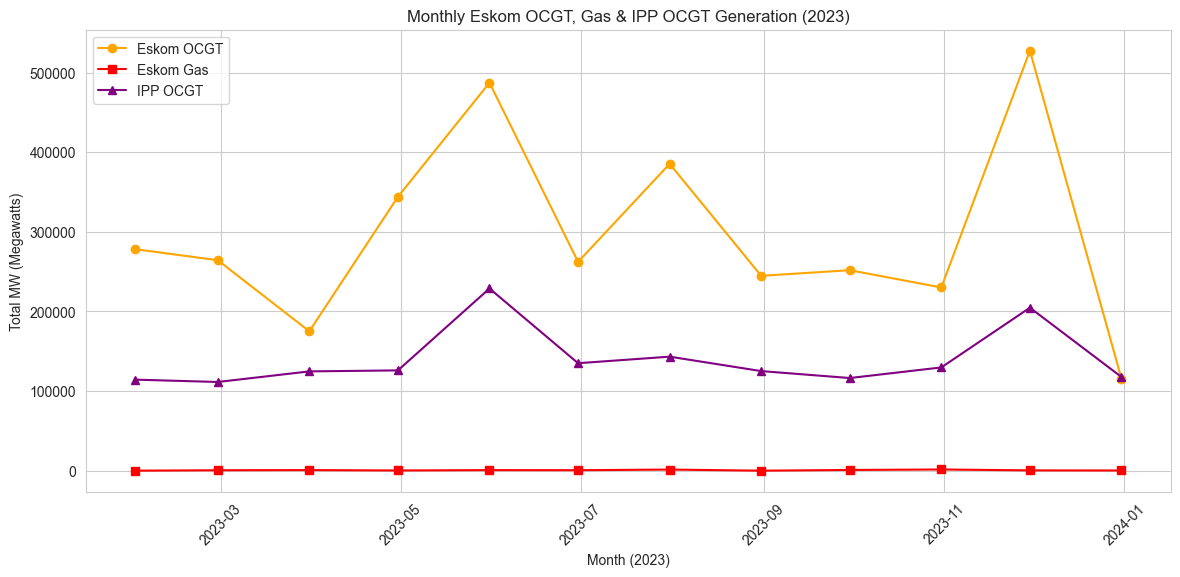

In [29]:
# Filter Data for the Year 2023
df_2023 = df[df.index.year == 2023]

# Select Relevant Columns
generation_cols = ["Eskom OCGT Generation", "Eskom Gas Generation", "Dispatchable IPP OCGT"]

# Verify that all columns exist
missing_cols = [col for col in generation_cols if col not in df.columns]
if missing_cols:
    raise KeyError(f"Missing columns in dataset: {missing_cols}")

# Convert Columns to Numeric
df_2023[generation_cols] = df_2023[generation_cols].apply(pd.to_numeric, errors='coerce')

# Resample Data Monthly (Summing Each Month)
df_monthly = df_2023[generation_cols].resample('M').sum()

# Plot Line Chart
plt.figure(figsize=(14, 6))
plt.plot(df_monthly.index, df_monthly["Eskom OCGT Generation"], label="Eskom OCGT", marker="o", linestyle="-", color="orange")
plt.plot(df_monthly.index, df_monthly["Eskom Gas Generation"], label="Eskom Gas", marker="s", linestyle="-", color="red")
plt.plot(df_monthly.index, df_monthly["Dispatchable IPP OCGT"], label="IPP OCGT", marker="^", linestyle="-", color="purple")

# Customize Plot
plt.xlabel("Month (2023)")
plt.ylabel("Total MW (Megawatts)")
plt.title("Monthly Eskom OCGT, Gas & IPP OCGT Generation (2023)")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)

# Show Plot
plt.show()

MODEL BUILDING

- Identify abnormal energy spikes.
-  Detect unusual power imports/exports.
- Find anomalies in manual load reduction.

In [30]:
#Libraries imported
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest

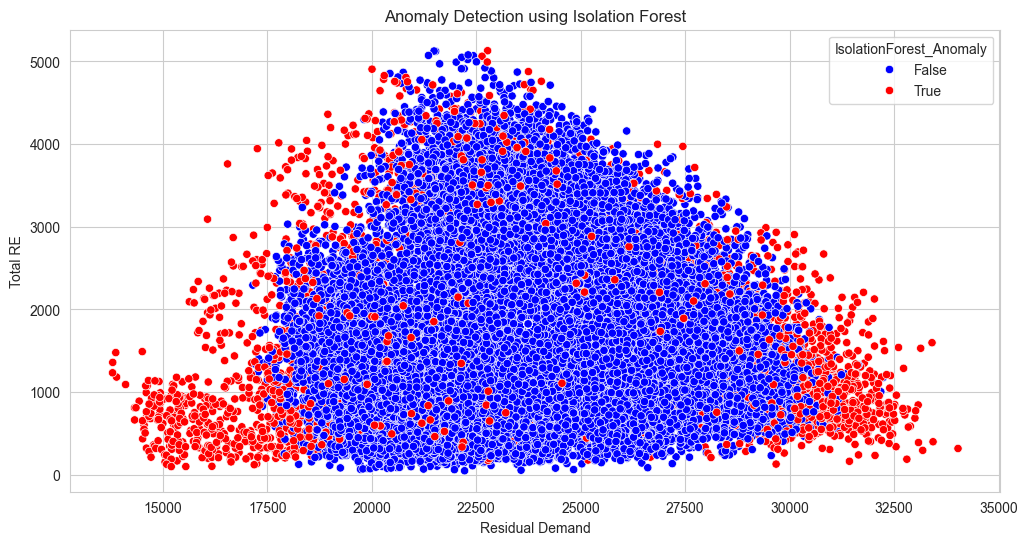

Anomalies detected by Isolation Forest:
                          Residual Demand  RSA Contracted Demand  \
Date Time Hour Beginning                                           
2020-04-01 00:00:00              15695.40              16758.232   
2020-04-01 01:00:00              15450.27              16401.964   
2020-04-01 02:00:00              15211.40              16136.822   
2020-04-01 03:00:00              15206.27              16169.168   
2020-04-01 04:00:00              15574.27              16502.843   

                          International Exports  International Imports  \
Date Time Hour Beginning                                                 
2020-04-01 00:00:00                    1704.954                 1069.0   
2020-04-01 01:00:00                    1716.990                  938.0   
2020-04-01 02:00:00                    1691.063                  848.0   
2020-04-01 03:00:00                    1657.440                  831.0   
2020-04-01 04:00:00                    

In [31]:
# Selecting relevant features
features = ["Residual Demand", "RSA Contracted Demand", "International Exports", 
            "International Imports", "Thermal Generation", "Total RE", 
             "Non Comm Sentout"]

# Drop rows with missing values
df = df[features].dropna()

# Standardize the features
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

# --- K-Means Clustering ---
num_clusters = 3  # You can optimize this using the Elbow Method
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(df_scaled)
df["KMeans_Cluster"] = kmeans_labels

# Identify outliers as points far from their cluster centers
distances = np.linalg.norm(df_scaled - kmeans.cluster_centers_[kmeans_labels], axis=1)
df["KMeans_Anomaly_Score"] = distances
threshold = np.percentile(distances, 95)  # Top 5% as anomalies
df["KMeans_Anomaly"] = df["KMeans_Anomaly_Score"] > threshold

# --- Isolation Forest for Anomaly Detection ---
isolation_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
df["IsolationForest_Score"] = isolation_forest.fit_predict(df_scaled)
df["IsolationForest_Anomaly"] = df["IsolationForest_Score"] == -1

# --- Visualize the Results ---
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x="Residual Demand", y="Total RE", 
                hue="IsolationForest_Anomaly", palette={True: "red", False: "blue"})
plt.title("Anomaly Detection using Isolation Forest")
plt.show()

# Print a sample of detected anomalies
print("Anomalies detected by Isolation Forest:")
print(df[df["IsolationForest_Anomaly"]].head())


Columns in the dataset: Index(['Date Time Hour Beginning', 'Original Res Forecast before Lockdown',
       'Residual Forecast', 'RSA Contracted Forecast',
       'Dispatchable Generation', 'Residual Demand', 'RSA Contracted Demand',
       'International Exports', 'International Imports', 'Thermal Generation',
       'Nuclear Generation', 'Eskom Gas Generation', 'Eskom OCGT Generation',
       'Hydro Water Generation', 'Pumped Water Generation', 'ILS Usage',
       'Manual Load_Reduction(MLR)', 'IOS Excl ILS and MLR',
       'Dispatchable IPP OCGT', 'Eskom Gas SCO', 'Eskom OCGT SCO',
       'Hydro Water SCO', 'Pumped Water SCO Pumping', 'Wind', 'PV', 'CSP',
       'Other RE', 'Total RE', 'Wind Installed Capacity',
       'PV Installed Capacity', 'CSP Installed Capacity',
       'Other RE Installed Capacity', 'Total RE Installed Capacity',
       'Installed Eskom Capacity', 'Total PCLF', 'Total UCLF', 'Total OCLF',
       'Total UCLF+OCLF', 'Non Comm Sentout', 'Drakensberg Gen Unit Hour

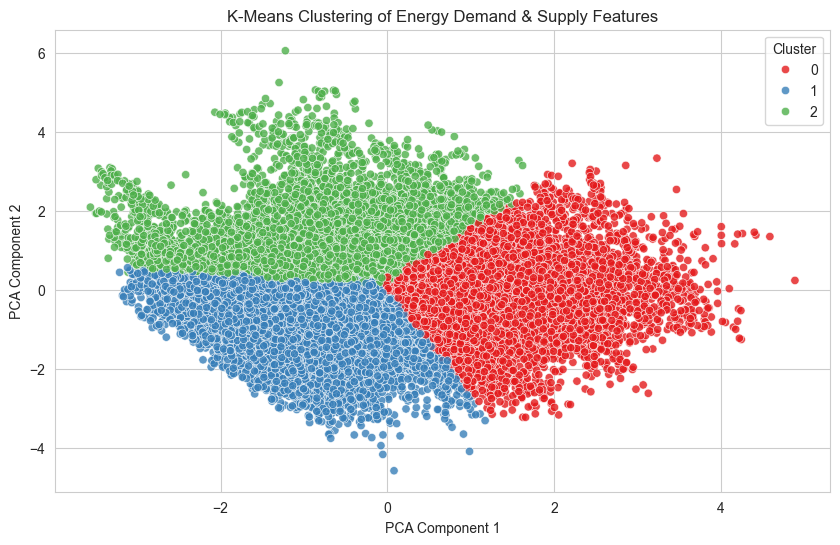

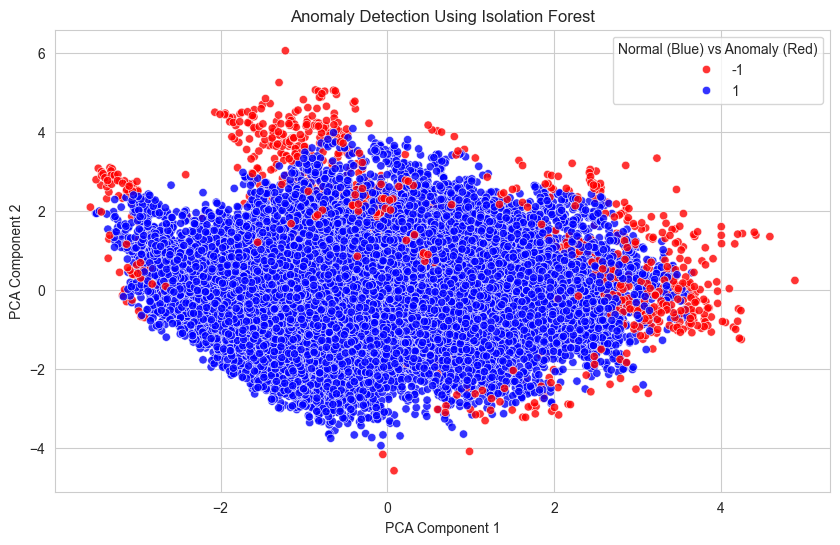

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA

# Load dataset
file_path = "data/ESK10705.csv"  # Update path if necessary
df = pd.read_csv(file_path)

# Clean column names
df.columns = df.columns.str.strip()

# Display column names to ensure correctness
print("Columns in the dataset:", df.columns)

# Verify if the datetime column exists
datetime_col = "Date Time Hour Beginning"
if datetime_col in df.columns:
    df[datetime_col] = pd.to_datetime(df[datetime_col], errors='coerce')
else:
    print(f"Column '{datetime_col}' not found in the dataset!")

# Extract time-based features only if datetime exists
if datetime_col in df:
    df["Hour of Day"] = df[datetime_col].dt.hour
    df["Day of Week"] = df[datetime_col].dt.dayofweek

# Define correct feature names (Ensure they match actual dataset)
correct_feature_names = {
    "Residual Demand": "Residual Demand",
    "RSA Contracted Demand": "RSA Contracted Demand",
    "International Exports": "International Exports",
    "International Imports": "International Imports",
    "Thermal Generation": "Thermal Generation",
    "Total RE": "Total RE",
    "Manual Load Reduction (MLR)": "Manual Load Reduction",
    "Non Comm Sentout": "Non Comm Sentout"
}

# Select available columns
available_features = [col for col in correct_feature_names.values() if col in df.columns]
available_features.extend(["Hour of Day", "Day of Week"])  # Add time-based features

df_selected = df[available_features].dropna()

# Normalize Features
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_selected)

# Apply K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df_selected["Cluster"] = kmeans.fit_predict(df_scaled)

# Apply DBSCAN Clustering
dbscan = DBSCAN(eps=1.5, min_samples=10)
df_selected["DBSCAN_Cluster"] = dbscan.fit_predict(df_scaled)

# Apply Isolation Forest for Anomaly Detection
iso_forest = IsolationForest(contamination=0.05, random_state=42)
df_selected["Anomaly"] = iso_forest.fit_predict(df_scaled)

# Use PCA for Visualization
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)
df_selected["PCA1"] = df_pca[:, 0]
df_selected["PCA2"] = df_pca[:, 1]

# Visualize K-Means Clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_selected["PCA1"], y=df_selected["PCA2"], hue=df_selected["Cluster"], palette="Set1", alpha=0.8)
plt.title("K-Means Clustering of Energy Demand & Supply Features")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()

# Visualize Anomalies (Isolation Forest)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_selected["PCA1"], y=df_selected["PCA2"], hue=df_selected["Anomaly"], palette={1: "blue", -1: "red"}, alpha=0.8)
plt.title("Anomaly Detection Using Isolation Forest")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Normal (Blue) vs Anomaly (Red)")
plt.grid(True)
plt.show()


 - Sudden drop in demand (possible meter tampering)
 - Huge spikes in demand (illegal connections)
 - High non-technical losses (NTL) (supply-demand mismatch)
 - Mismatch between forecast vs actual usage

 User dataset loaded successfully.
 Location dataset loaded successfully.
 Merged dataset saved successfully.
 Found 39240 fraud cases.
 No valid fraud locations found to plot.
 Shapefile loaded successfully.
 Error loading shapefile: aspect must be finite and positive 


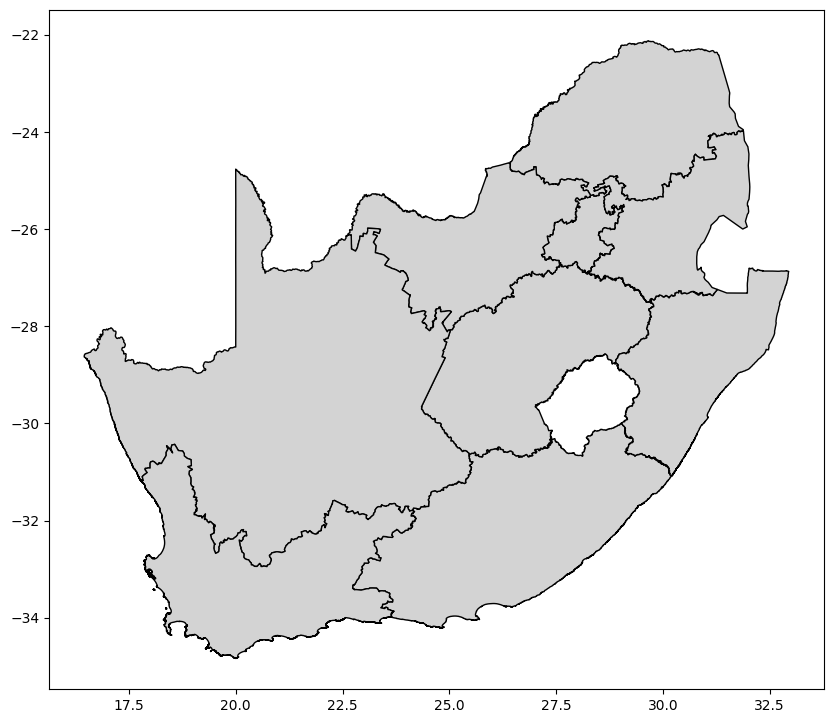

In [25]:
# --- Import Libraries ---
import pandas as pd
import numpy as np
import folium
import geopandas as gpd
import fiona
from pyproj import CRS
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

# --- Enable SHAPE_RESTORE_SHX option ---
fiona.drvsupport.supported_drivers["ESRI Shapefile"] = "raw"

# --- Load Datasets ---
user_file = "data/ESK10705.csv"
location_file = "data/location_data.csv"
shapefile_path = "zaf_adm_sadb_ocha_20201109_SHP/zaf_admbnda_adm1_sadb_ocha_20201109.shp"  # South African provinces

try:
    user_data = pd.read_csv(user_file)
    print(" User dataset loaded successfully.")
except FileNotFoundError:
    print(f" Error: {user_file} not found.")
    exit()

try:
    location_data = pd.read_csv(location_file)
    print(" Location dataset loaded successfully.")
except FileNotFoundError:
    print(f" Error: {location_file} not found.")
    exit()

# --- Convert "Date Time Hour Beginning" to datetime format ---
user_data["Date Time Hour Beginning"] = pd.to_datetime(user_data["Date Time Hour Beginning"], errors="coerce")
location_data["Date Time Hour Beginning"] = pd.to_datetime(location_data["Date Time Hour Beginning"], errors="coerce")

# --- Merge datasets on "Date Time Hour Beginning" ---
merged_data = user_data.merge(location_data, on="Date Time Hour Beginning", how="left")

# Validate merge success
if "Latitude" not in merged_data.columns or "Longitude" not in merged_data.columns:
    print(" Warning: Latitude/Longitude columns missing after merge. Check column names.")

# Save merged dataset
merged_data.to_csv("data/merged_dataset.csv", index=False)
print(" Merged dataset saved successfully.")

# --- Detect Fraudulent Activities ---
df = merged_data.copy()

# --- Create Fraud Indicators ---
df["Demand Drop"] = df["Residual Demand"].pct_change() < -0.5  # 50%+ drop
df["High Spike"] = df["Residual Demand"].pct_change() > 1  # 100%+ increase
df["Mismatch"] = abs(df["Residual Demand"] - df["RSA Contracted Demand"]) > df["Residual Demand"] * 0.3

# --- Select Features for Fraud Detection ---
fraud_features = [
    "Residual Demand", "RSA Contracted Demand", "International Imports", "International Exports", 
    "Manual Load_Reduction(MLR)", "Non Comm Sentout"
]

# Handle missing values
df_fraud = df[fraud_features].dropna()

# Standardize data
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_fraud)

# Adjust contamination dynamically
fraud_ratio = 0.02 if len(df_fraud) > 100 else 0.1  

# Fit Isolation Forest (Anomaly Detection)
iso_forest = IsolationForest(contamination=fraud_ratio, random_state=42)
fraud_predictions = iso_forest.fit_predict(df_scaled)

# Assign fraud labels back to the original DataFrame
df.loc[df_fraud.index, "Fraudulent"] = fraud_predictions
df["Fraudulent"] = df["Fraudulent"].apply(lambda x: "Fraud" if x == -1 else "Normal")

# Merge fraud conditions
df["Suspected Fraud"] = df[["Demand Drop", "High Spike", "Mismatch"]].any(axis=1)
df.loc[df["Suspected Fraud"], "Fraudulent"] = "Fraud"

# --- Display Potential Fraud Cases ---
fraud_cases = df[df["Fraudulent"] == "Fraud"]
print(f" Found {len(fraud_cases)} fraud cases.")

# --- Validate Latitude & Longitude ---
fraud_cases = fraud_cases.dropna(subset=["Latitude", "Longitude"])

# --- Check if fraud locations are within South Africa ---
fraud_cases = fraud_cases[
    (fraud_cases["Latitude"] >= -35) & (fraud_cases["Latitude"] <= -22) &  
    (fraud_cases["Longitude"] >= 16) & (fraud_cases["Longitude"] <= 33)
]

# --- Plot Fraudulent Locations on a Folium Map ---
if not fraud_cases.empty:
    map_center = [fraud_cases["Latitude"].mean(), fraud_cases["Longitude"].mean()]
    fraud_map = folium.Map(location=map_center, zoom_start=7)

    for _, row in fraud_cases.iterrows():
        folium.Marker(
            location=[row["Latitude"], row["Longitude"]],
            popup=f"Fraud Detected: {row['Residual Demand']} MW",
            icon=folium.Icon(color="red")
        ).add_to(fraud_map)

    fraud_map.save("fraud_map.html")
    print(" Fraud detection map saved as fraud_map.html")
else:
    print(" No valid fraud locations found to plot.")

# --- Load South African Map Using GeoPandas ---
try:
    sa_provinces = gpd.read_file(shapefile_path)
    print(" Shapefile loaded successfully.")
    
    # Set CRS to WGS84
    mod_clarke_1880_crs = CRS.from_proj4("+proj=longlat +datum=WGS84 +no_defs")
    sa_provinces = sa_provinces.to_crs(mod_clarke_1880_crs)

    # Convert fraud cases to a GeoDataFrame
    gdf_fraud = gpd.GeoDataFrame(
        fraud_cases, 
        geometry=gpd.points_from_xy(fraud_cases.Longitude, fraud_cases.Latitude),
        crs="EPSG:4326"
    )

    # Plot the fraud cases on the South African province map
    ax = sa_provinces.plot(figsize=(10, 10), color="lightgrey", edgecolor="black")
    gdf_fraud.plot(ax=ax, color="red", markersize=20, label="Fraud Cases")

    ax.set_title("Fraud Cases Detected in South Africa")
    ax.legend()
    print(" Fraud map plotted using GeoPandas.")
except Exception as e:
    print(f" Error loading shapefile: {e}")


C:\Users\User\AppData\Local\Temp\ipykernel_13500\4064214489.py:14: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


 Dataset loaded successfully.
 Available Columns: Index(['Date Time Hour Beginning', 'Original Res Forecast before Lockdown',
       'Residual Forecast', 'RSA Contracted Forecast',
       'Dispatchable Generation', 'Residual Demand', 'RSA Contracted Demand',
       'International Exports', 'International Imports', 'Thermal Generation',
       'Nuclear Generation', 'Eskom Gas Generation', 'Eskom OCGT Generation',
       'Hydro Water Generation', 'Pumped Water Generation', 'ILS Usage',
       'Manual Load_Reduction(MLR)', 'IOS Excl ILS and MLR',
       'Dispatchable IPP OCGT', 'Eskom Gas SCO', 'Eskom OCGT SCO',
       'Hydro Water SCO', 'Pumped Water SCO Pumping', 'Wind', 'PV', 'CSP',
       'Other RE', 'Total RE', 'Wind Installed Capacity',
       'PV Installed Capacity', 'CSP Installed Capacity',
       'Other RE Installed Capacity', 'Total RE Installed Capacity',
       'Installed Eskom Capacity', 'Total PCLF', 'Total UCLF', 'Total OCLF',
       'Total UCLF+OCLF', 'Non Comm Sentout', 

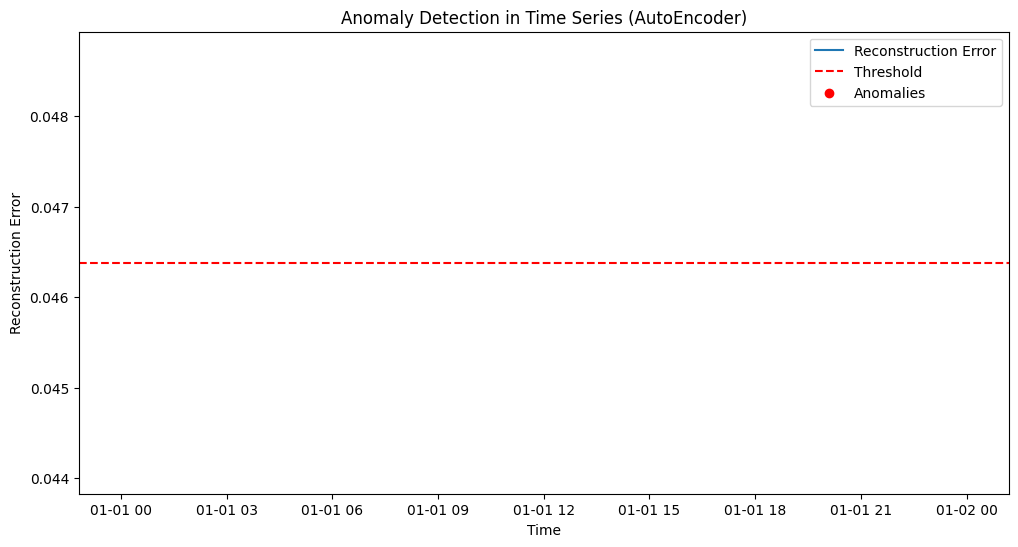

 Detected 544 anomalies.


In [31]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# --- Load and Preprocess Data ---
file_path = "data/merged_dataset.csv"

# Load dataset safely
try:
    df = pd.read_csv(file_path)
    print(" Dataset loaded successfully.")
except FileNotFoundError:
    print(f" Error: File '{file_path}' not found.")
    exit()

# Clean column names (remove leading/trailing spaces)
df.columns = df.columns.str.strip()
print(" Available Columns:", df.columns)

# Ensure correct datetime parsing
datetime_col = "Date Time Hour Beginning"
if datetime_col in df.columns:
    df[datetime_col] = pd.to_datetime(df[datetime_col], errors="coerce")
    df.set_index(datetime_col, inplace=True)
else:
    print(f" Error: Column '{datetime_col}' not found in dataset.")
    exit()

# --- Select relevant features ---
features = ["Residual Demand", "International Imports", "Manual Load_Reduction(MLR)", "Non Comm Sentout"]

# Check if the columns are available in the dataframe
missing_columns = [col for col in features if col not in df.columns]
if missing_columns:
    print(f" Error: The following columns are missing: {', '.join(missing_columns)}")
    exit()

# Drop missing values for selected features
df = df[features].dropna()

# Normalize data
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df)

# Split into training (normal data) and testing (which may contain anomalies)
train_size = int(len(df_scaled) * 0.7)
train, test = df_scaled[:train_size], df_scaled[train_size:]

# --- Build AutoEncoder Model ---
input_dim = train.shape[1]
encoding_dim = 3  # Dimension for compressed representation

input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation="relu")(input_layer)
decoded = Dense(input_dim, activation="sigmoid")(encoded)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer="adam", loss="mse")

# --- Train AutoEncoder ---
print(" Training AutoEncoder...")
autoencoder.fit(train, train, epochs=50, batch_size=32, shuffle=True, validation_data=(test, test))

# --- Compute Reconstruction Error ---
train_reconstructions = autoencoder.predict(train)
train_loss = np.mean(np.abs(train - train_reconstructions), axis=1)

test_reconstructions = autoencoder.predict(test)
test_loss = np.mean(np.abs(test - test_reconstructions), axis=1)

# Set threshold based on 95th percentile of normal data
threshold = np.percentile(train_loss, 95)
print(f" Anomaly Detection Threshold: {threshold}")

# --- Detect Anomalies ---
anomalies = test_loss > threshold
df_anomalies = df.iloc[train_size:][anomalies]

# --- Plot Results ---
plt.figure(figsize=(12, 6))
plt.plot(df.index[train_size:], test_loss, label="Reconstruction Error")
plt.axhline(threshold, color="red", linestyle="--", label="Threshold")
plt.scatter(df_anomalies.index, test_loss[anomalies], color="red", label="Anomalies")
plt.legend()
plt.title("Anomaly Detection in Time Series (AutoEncoder)")
plt.xlabel("Time")
plt.ylabel("Reconstruction Error")
plt.show()

print(f" Detected {len(df_anomalies)} anomalies.")


KeyError: "None of [Index(['Energy Demand (MW)', 'Energy Generation (MW)', 'Grid Frequency (Hz)',\n       'Voltage (kV)', 'Transmission Losses (MW)', 'Distribution Losses (MW)'],\n      dtype='object')] are in the [columns]"

In [ ]:
import pandas as pd
import numpy as np
import geopandas as gpd
import folium
import fiona
import matplotlib.pyplot as plt
from shapely.geometry import Point
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# --- Load Datasets ---
user_file = "data/ESK10705.csv"
location_file = "data/location_data.csv"

# Enable SHAPE_RESTORE_SHX option for missing .shx files
fiona.drvsupport.supported_drivers["ESRI Shapefile"] = "raw"

# Load user dataset
try:
    user_data = pd.read_csv(user_file)
    print(" User dataset loaded successfully.")
except FileNotFoundError:
    print(f" Error: {user_file} not found.")
    exit()

# Load location dataset
try:
    location_data = pd.read_csv(location_file)
    print(" Location dataset loaded successfully.")
except FileNotFoundError:
    print(f" Error: {location_file} not found.")
    exit()

# --- Convert "Date Time Hour Beginning" to datetime format ---
user_data["Date Time Hour Beginning"] = pd.to_datetime(user_data["Date Time Hour Beginning"], errors="coerce")
location_data["Date Time Hour Beginning"] = pd.to_datetime(location_data["Date Time Hour Beginning"], errors="coerce")

# --- Merge datasets on "Date Time Hour Beginning" ---
merged_data = user_data.merge(location_data, on="Date Time Hour Beginning", how="left")
merged_data.to_csv("data/merged_dataset.csv", index=False)
print(" Merged dataset saved successfully.")

# --- Detect Fraudulent Activities ---
df = merged_data.copy()

# --- Create Fraud Indicators ---
df["Demand Drop"] = df["Residual Demand"].pct_change() < -0.5  # 50%+ drop
df["High Spike"] = df["Residual Demand"].pct_change() > 1  # 100%+ increase
df["Mismatch"] = abs(df["Residual Demand"] - df["RSA Contracted Demand"]) > df["Residual Demand"] * 0.3

# --- Select Features for Fraud Detection ---
fraud_features = [
    "Residual Demand", "RSA Contracted Demand", "International Imports", "International Exports",
    "Manual Load_Reduction(MLR)", "Non Comm Sentout"
]

# Handle missing values
df_fraud = df[fraud_features].dropna()

# --- Split Data into Training & Testing Sets ---
X_train, X_test = train_test_split(df_fraud, test_size=0.2, random_state=42)

# Standardize data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Isolation Forest Model
iso_forest = IsolationForest(contamination=0.02, random_state=42)
iso_forest.fit(X_train_scaled)

# Predict fraud on test set
y_test_pred = iso_forest.predict(X_test_scaled)
y_test_pred = np.where(y_test_pred == -1, 1, 0)  # Convert (-1 = fraud) to (1 = fraud, 0 = normal)

# Assign labels to the dataset
df.loc[X_test.index, "Fraudulent"] = y_test_pred
df["Fraudulent"] = df["Fraudulent"].apply(lambda x: "Fraud" if x == 1 else "Normal")

# --- Evaluate Model Performance ---
y_test_actual = np.zeros_like(y_test_pred)  # Assuming no labeled fraud data, treat all as normal (0)
print("\n Classification Report (Test Set):")
print(classification_report(y_test_actual, y_test_pred))

# --- Display Fraud Cases ---
fraud_cases = df[df["Fraudulent"] == "Fraud"]
print(f" Found {len(fraud_cases)} fraud cases.")

# --- Validate Latitude & Longitude ---
if "Latitude" not in df.columns or "Longitude" not in df.columns:
    print(" Error: Latitude/Longitude columns not found in dataset.")
else:
    fraud_cases = fraud_cases.dropna(subset=["Latitude", "Longitude"])
    
    # Filter only valid South African locations
    fraud_cases = fraud_cases[
        (fraud_cases["Latitude"].between(-35, -22)) & 
        (fraud_cases["Longitude"].between(16, 33))
    ]

    if fraud_cases.empty:
        print(" No valid fraud locations found after filtering incorrect coordinates.")
    else:
        print(f" {len(fraud_cases)} fraud cases with valid coordinates found.")

# --- Plot Fraud Locations on Folium Map ---
if not fraud_cases.empty:
    map_center = [fraud_cases["Latitude"].mean(), fraud_cases["Longitude"].mean()]
    fraud_map = folium.Map(location=map_center, zoom_start=7)

    for _, row in fraud_cases.iterrows():
        folium.Marker(
            location=[row["Latitude"], row["Longitude"]],
            popup=f"Fraud Detected: {row['Residual Demand']} MW",
            icon=folium.Icon(color="red")
        ).add_to(fraud_map)

    fraud_map.save("fraud_map.html")
    print(" Fraud detection map saved as fraud_map.html")
else:
    print(" No valid fraud locations found to plot.")

# --- GeoPandas Map Plotting ---
shapefile_path = "zaf_adm_sadb_ocha_20201109_SHP/zaf_admbnda_adm1_sadb_ocha_20201109.shp"
try:
    sa_provinces = gpd.read_file(shapefile_path)
    print(" Shapefile loaded successfully.")

    if not fraud_cases.empty:
        gdf_fraud = gpd.GeoDataFrame(
            fraud_cases, 
            geometry=gpd.points_from_xy(fraud_cases.Longitude, fraud_cases.Latitude),
            crs="EPSG:4326"
        )

        # Ensure valid geometries
        if not gdf_fraud.geometry.is_valid.all():
            gdf_fraud = gdf_fraud.set_geometry(gdf_fraud.geometry.buffer(0))

        if gdf_fraud.empty:
            print(" No valid fraud locations to plot on GeoPandas map.")
        else:
            fig, ax = plt.subplots(figsize=(10, 10))
            sa_provinces.plot(ax=ax, color="lightgrey", edgecolor="black")
            gdf_fraud.plot(ax=ax, color="red", markersize=20, label="Fraud Cases")

            ax.set_title("Fraud Cases Detected in South Africa")
            ax.legend()
            plt.show()
            print("Fraud map plotted using GeoPandas.")
    else:
        print(" No valid fraud locations to plot in GeoPandas.")
except Exception as e:
    print(f" Error loading shapefile: {e}")


✅ User dataset loaded successfully.
✅ Location dataset loaded successfully.
✅ Merged dataset saved successfully.

🔍 Classification Report (Test Set):
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      7848
           1       0.00      0.00      0.00         0

    accuracy                           0.98      7848
   macro avg       0.50      0.49      0.49      7848
weighted avg       1.00      0.98      0.99      7848

🔍 Found 180 fraud cases.
⚠️ No valid fraud locations found after filtering incorrect coordinates.
⚠️ No valid fraud locations found to plot.


c:\users\user\appdata\local\programs\python\python311\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\users\user\appdata\local\programs\python\python311\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\users\user\appdata\local\programs\python\python311\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

✅ Shapefile loaded successfully.
 No valid fraud locations to plot in GeoPandas.


In [37]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv("data/ESK10705.csv")

# Select relevant features
features = [
    "Residual Demand", "RSA Contracted Demand", "International Exports", "International Imports",
    "Thermal Generation", "Nuclear Generation", "Eskom Gas Generation", "Non Comm Sentout"
]
X = df[features].values

# Generate Anomalies column if missing
if "Anomalies" not in df.columns:
    df["Anomalies"] = (df["Residual Demand"].pct_change() < -0.5).astype(int)  # Example fraud indicator

# Ensure `y` is 1D
y = df["Anomalies"].values.reshape(-1)  # ✅ Fix the shape issue

# Normalize Data
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Reshape for CNN (samples, time steps, features)
X_scaled = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))  # time_steps=1

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Build CNN Model (No MaxPooling1D due to time_steps=1)
model = Sequential([
    Conv1D(filters=64, kernel_size=1, activation="relu", input_shape=(1, X_train.shape[2])),
    Flatten(),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")  # ✅ Binary output
])

# Compile Model
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# Train Model
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))  # ✅ Matching shape

# Evaluate Model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"✅ Test Accuracy: {accuracy:.2f}")

# Predict Fraud Cases
y_pred = (model.predict(X_test) > 0.5).astype("int32")

# Save Model
model.save("fraud_detection_cnn.h5")
print("🚀 Model saved for real-time fraud detection!")


Epoch 1/20


c:\users\user\appdata\local\programs\python\python311\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


959/959 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9973 - loss: 0.5901 - val_accuracy: 1.0000 - val_loss: 0.3544
Epoch 2/20
959/959 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 1.0000 - loss: 0.3063 - val_accuracy: 1.0000 - val_loss: 0.1951
Epoch 3/20
959/959 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 1.0000 - loss: 0.1713 - val_accuracy: 1.0000 - val_loss: 0.1149
Epoch 4/20
959/959 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 1.0000 - loss: 0.1021 - val_accuracy: 1.0000 - val_loss: 0.0709
Epoch 5/20
959/959 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 1.0000 - loss: 0.0635 - val_accuracy: 1.0000 - val_loss: 0.0451
Epoch 6/20
959/959 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 1.0000 - loss: 0.0407 - val_accuracy: 1.0000 - val_loss: 0.0293
Epoch 7/20
959/959 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 1.0000 - loss: 0.0265 - val_accuracy: 1.0000 - val_loss: 0.0192
Epoch 8/20
959/959 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 1.0000 - loss: 0.0174 - val_accuracy: 1.0000 -

🚀 Model saved for real-time fraud detection!
